##  Importing Libraries

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2

print("TensorFlow version:", tf.__version__)
print(tf.config.list_physical_devices('GPU'))

C:\Users\LENOVO\anaconda3\envs\Tensorflow_Env\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


TensorFlow version: 2.10.0
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Loading Model

In [2]:
model = tf.keras.models.load_model('trained_soil_model.keras')
model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_38 (Conv2D)          (None, 128, 128, 32)      896       
                                                                 
 conv2d_39 (Conv2D)          (None, 126, 126, 32)      9248      
                                                                 
 max_pooling2d_19 (MaxPoolin  (None, 63, 63, 32)       0         
 g2D)                                                            
                                                                 
 conv2d_40 (Conv2D)          (None, 63, 63, 64)        18496     
                                                                 
 conv2d_41 (Conv2D)          (None, 61, 61, 64)        36928     
                                                                 
 max_pooling2d_20 (MaxPoolin  (None, 30, 30, 64)       0         
 g2D)                                                 

## Define Class Names

In [3]:
class_names = [
    'Alluvial_Soil',
    'Arid_Soil',
    'Black_Soil',
    'Laterite_Soil',
    'Mountain_Soil',
    'Red_Soil',
    'Yellow_Soil'
]

## Visualizing Single Image of Test set

In [4]:
import os
test_image_path = "D:/Soil Type identification/Train/Alluvial_Soil/1 - Copy.jpg"

## Reading Image

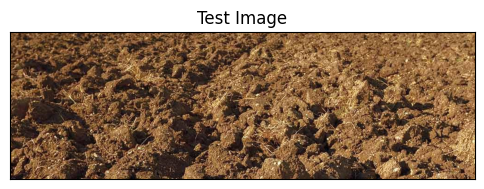

In [5]:
img = cv2.imread(test_image_path)
if img is not None:
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Displaying Image
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title("Test Image")
    plt.xticks([])
    plt.yticks([])
    plt.show()
else:
    print(f"Error: Could not load image from {test_image_path}")

## Testing Model

In [6]:
image = tf.keras.preprocessing.image.load_img(test_image_path, target_size=(128, 128))
input_arr = tf.keras.preprocessing.image.img_to_array(image)
input_arr = np.array([input_arr]) / 255.0  # Convert single image to a batch and normalize
print(f"Input shape: {input_arr.shape}")

prediction = model.predict(input_arr)
print(f"Prediction shape: {prediction.shape}")

result_index = np.argmax(prediction)
print(f"Result index: {result_index}")

# Cell 6: Display Result
model_prediction = class_names[result_index]
confidence = np.max(prediction) * 100

print(f"\n✅ Predicted Soil Type: {model_prediction.replace('_', ' ')}")
print(f"✅ Confidence: {confidence:.2f}%")


Input shape: (1, 128, 128, 3)
1/1 [==============================] - 4s 4s/step
Prediction shape: (1, 7)
Result index: 0

✅ Predicted Soil Type: Alluvial Soil
✅ Confidence: 53.83%


## Display with image

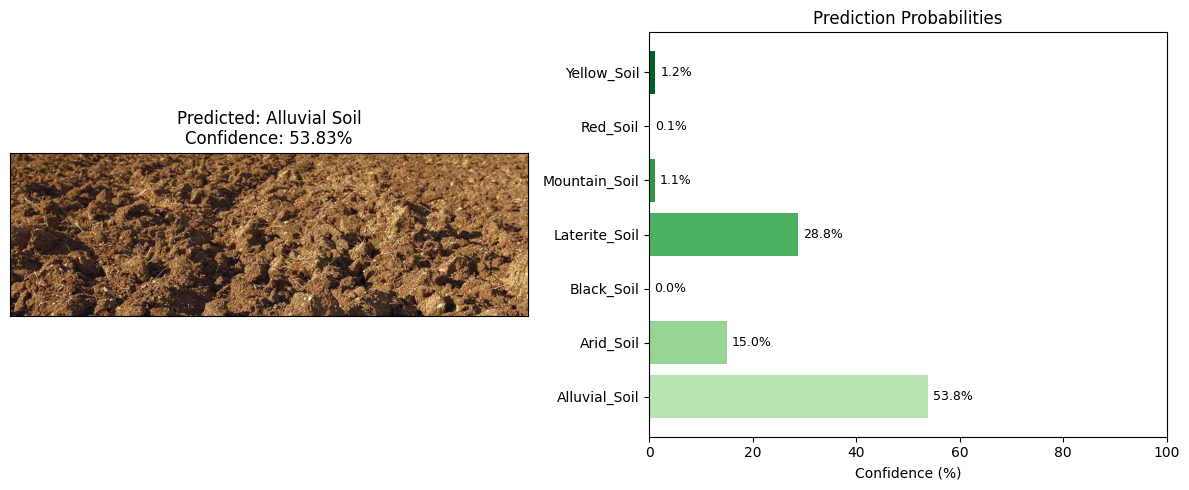

In [7]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title(f"Predicted: {model_prediction.replace('_', ' ')}\nConfidence: {confidence:.2f}%", fontsize=12)
plt.xticks([])
plt.yticks([])

plt.subplot(1, 2, 2)
colors = plt.cm.Greens(np.linspace(0.3, 0.9, len(class_names)))
bars = plt.barh(class_names, prediction[0] * 100, color=colors)
plt.xlabel('Confidence (%)')
plt.title('Prediction Probabilities')
plt.xlim(0, 100)

for bar, prob in zip(bars, prediction[0] * 100):
     plt.text(prob + 1, bar.get_y() + bar.get_height()/2, f'{prob:.1f}%', 
            va='center', fontsize=9)

plt.tight_layout()
plt.show()